In [1]:
# Importando os pacotes das bibliotecas
import pandas as pd

In [4]:
# Carregando base de dados
df = pd.read_excel("../data/raw/telco_customer_churn.xlsx", sheet_name=0)

#Vizualiando o dataset
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,3325-['N' 'S' 'A' 'U' 'G'],Female,0,Yes,No,61,Yes,No,Fiber optic,No internet service,...,No internet service,No,No,No,Month-to-month,Yes,Mailed check,82.76,5045.65,No
1,3329-['L' 'E' 'Q' 'M' 'H'],Male,0,Yes,No,8,No,No phone service,Fiber optic,No,...,No,Yes,No,No,Month-to-month,Yes,Electronic check,56.44,445.25,Yes
2,6955-['P' 'W' 'Q' 'D' 'X'],Male,0,Yes,No,41,Yes,No,DSL,No,...,No,No,Yes,No,Two year,No,Mailed check,97.57,3995.44,Yes
3,1409-['S' 'L' 'G' 'M' 'D'],Male,1,Yes,No,46,Yes,No,DSL,No,...,No,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),110.33,5087.22,No
4,9364-['M' 'J' 'O' 'G' 'Z'],Female,0,Yes,No,33,Yes,No,DSL,No,...,No internet service,No,Yes,No,Two year,Yes,Credit card (automatic),63.35,2101.75,No


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


Esse é o clássico dataset de telco Customer Churn (Rotatividade de Clientes de Telecomunicações).
Com base no df.info(), temos:
* 7.043 linhas e 21 colunas.
* Zero valores nulos (non-null em todas as colunas).
* A coluna alvo (churn) está presente para fazermos um modelo de classificação preditiva, além de variáveis demográficas, serviços contratados e cobranças (MonthlyCharges, TotalCharges).

In [7]:
# Análise Exploratória de Dados (EDA)
# Verifica a distribuição do Churn
print(df['Churn'].value_counts())
print('\nProcentagem:')
print(df['Churn'].value_counts(normalize=True) * 100)

Churn
No     4567
Yes    2476
Name: count, dtype: int64

Procentagem:
Churn
No     64.844526
Yes    35.155474
Name: proportion, dtype: float64


Temos uma taxa de churn de aproximadamente 35,15% (2.476 clientes cancelaram).

### 1. Relação Entre o Tipo de Contrato e Churn

In [11]:
# Tabela cruzada entre Contract e Churn
print(pd.crosstab(df['Contract'], df['Churn'], normalize='index')*100)

Churn                  No        Yes
Contract                            
Month-to-month  56.495828  43.504172
One year        76.628895  23.371105
Two year        77.646240  22.353760


Analisando os Resultados
Analisando a tabela, podemos tirar conclusões muito claras sobre o comportamento dos clientes:

* Month-to-month (Contrato Mensal):
    * No (Permaneceu): 56,50%
    * Yes (Cancelou): 43,50%
    * Conclusão: Quase metade dos clientes que possuem contratos mês a mês acabaram cancelando o serviço. É o perfil de maior risco, pois não há fidelidade de longo prazo.

* One year (Contrato de 1 ano):
    * No (Permaneceu): 76,63%
    * Yes (Cancelou): 23,37%
    * Conclusão: Quando o cliente se compromete por 1 ano, a taxa de cancelamento cai drasticamente pela metade (para cerca de 23%).(\)

* Two year (Contrato de 2 anos):
    * No (Permaneceu): 77,65%
    * Yes (Cancelou): 22,35%
    * Conclusão: Surpreendentemente, a taxa de churn de 2 anos é muito próxima à de 1 ano (cerca de 22%), mostrando que o grande divisor de águas na retenção não é o tempo de contrato em sim, mas sim sair do modelo estritamente mensal.

In [13]:
# Gerando o gráfico | Relação entre o tipo de contrato e churn
# Importando os pacotes das biliotecas
import matplotlib.pyplot as plt
import seaborn as sns

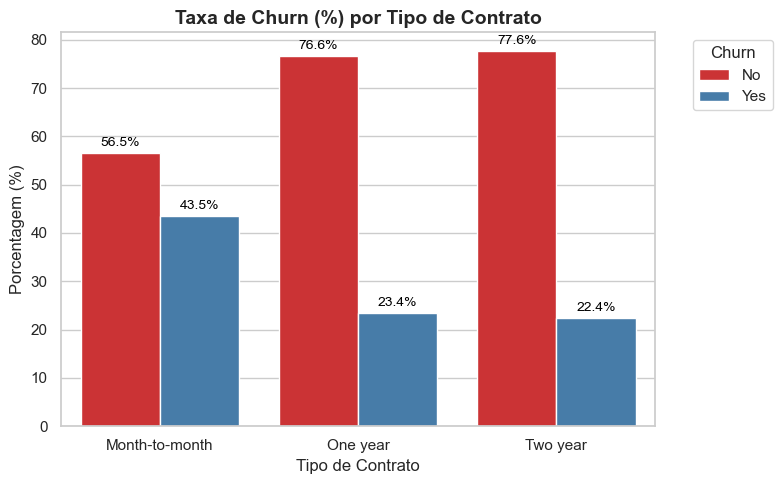

In [18]:
# Calculando a tabela em porcentagem por linha
df_pct = pd.crosstab(df['Contract'], df['Churn'], normalize='index') * 100
df_pct = df_pct.reset_index()

# Transformando o formato para o Seaborn (melt)
df_melted = df_pct.melt(id_vars='Contract', value_vars=['No', 'Yes'], 
                        var_name='Churn', value_name='Porcentagem')

# Plotando o gráfico de barras percentual
plt.figure(figsize=(8, 5))
ax = sns.barplot(data=df_melted, x='Contract', y='Porcentagem', hue='Churn', palette='Set1')

plt.title('Taxa de Churn (%) por Tipo de Contrato', fontsize=14, fontweight='bold')
plt.xlabel('Tipo de Contrato', fontsize=12)
plt.ylabel('Porcentagem (%)', fontsize=12)
plt.legend(title='Churn', bbox_to_anchor=(1.05, 1), loc='upper left')

# Adicionando a porcentagem em cima das barras
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{height:.1f}%',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom',
                    fontsize=10, color='black',
                    xytext=(0, 3),
                    textcoords='offset points')

plt.tight_layout()
plt.show()

### 2. Analisando o Impacto do Tipo de Internet e Pagamento

In [20]:
# Tabela cruzada para InternetService normalizada por linha em porcentagem
print(pd.crosstab(df['InternetService'], df['Churn'], normalize='index') * 100)

Churn                   No        Yes
InternetService                      
DSL              64.340278  35.659722
Fiber optic      65.256364  34.743636
No               65.065502  34.934498


In [21]:
print(df.isnull().sum())

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


#### Relatório completo em HTML com estatísticas, gráficos de correlação, alertas de qualidade e distribuição de todas as variáveis de uma só vez.

In [22]:
# Importando o pacote da biblioteca
from ydata_profiling import ProfileReport

In [26]:
#Gerando o relatório de profiling
profile = ProfileReport (df, title = 'Relatório de EDA - Telco Churn', explorative=True)

#Salvar como arquivo HTLM na pasta 'reports/' do projeto
caminho_relatorio = ('../reports/relatoriio_eda_churn.html')
profile.to_file(caminho_relatorio)

#Informa que o processo terminou
print(f'Relatório gerado e salvo com sucesso na parta reports: {caminho_relatorio}')

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

Relatório gerado e salvo com sucesso na parta reports: ../reports/relatoriio_eda_churn.html
